In [14]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator

#direktori dataset
train_dir = "intel-image-classification/seg_train/seg_train"
val_dir = "intel-image-classification/seg_test/seg_test"

#Augmentasi data
train_datagen = ImageDataGenerator(rescale=1./255, rotation_range=20,zoom_range=0.2, horizontal_flip=True)
val_datagen = ImageDataGenerator(rescale=1./255)

train_generator = train_datagen.flow_from_directory(train_dir,target_size=(150, 150),batch_size=32,class_mode='categorical')
val_generator = val_datagen.flow_from_directory(val_dir,target_size=(150,150),batch_size=32,class_mode='categorical')

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout 

# Definisi model CNN
model = Sequential([
 Conv2D(32, (3,3), activation='relu', input_shape=(150, 150, 3)),
 MaxPooling2D(2,2),
 Conv2D(64, (3,3), activation='relu'),
 MaxPooling2D(2,2),
 Flatten(),
 Dense(128, activation='relu'),
 Dropout(0.5),
 Dense(6, activation='softmax')
])

# Kompilasi model
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

# Training model
model.fit(train_generator, validation_data=val_generator, epochs=10)

# Simpan model
model.save('cnn_model.h5') 



Found 14034 images belonging to 6 classes.
Found 3000 images belonging to 6 classes.
Epoch 1/10
439/439 ━━━━━━━━━━━━━━━━━━━━ 225s 505ms/step - accuracy: 0.4603 - loss: 1.6721 - val_accuracy: 0.6527 - val_loss: 0.9168
Epoch 2/10
439/439 ━━━━━━━━━━━━━━━━━━━━ 191s 435ms/step - accuracy: 0.6235 - loss: 0.9905 - val_accuracy: 0.7060 - val_loss: 0.7723
Epoch 3/10
439/439 ━━━━━━━━━━━━━━━━━━━━ 190s 433ms/step - accuracy: 0.6645 - loss: 0.9000 - val_accuracy: 0.7407 - val_loss: 0.7038
Epoch 4/10
439/439 ━━━━━━━━━━━━━━━━━━━━ 189s 431ms/step - accuracy: 0.7086 - loss: 0.8171 - val_accuracy: 0.7433 - val_loss: 0.6654
Epoch 5/10
439/439 ━━━━━━━━━━━━━━━━━━━━ 185s 421ms/step - accuracy: 0.7253 - loss: 0.7613 - val_accuracy: 0.7930 - val_loss: 0.6196
Epoch 6/10
439/439 ━━━━━━━━━━━━━━━━━━━━ 196s 445ms/step - accuracy: 0.7421 - loss: 0.7202 - val_accuracy: 0.8130 - val_loss: 0.5710
Epoch 7/10
439/439 ━━━━━━━━━━━━━━━━━━━━ 195s 443ms/step - accuracy: 0.7556 - loss: 0.6816 - val_accuracy: 0.8207 - val_loss

In [7]:
pip install scipy

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 23.2.1 -> 25.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [15]:
import cv2
import numpy as np
from tensorflow.keras.models import load_model

 # Load model yang telah dilatih
model = load_model('cnn_model.h5')

 # Load label kelas
class_labels = list(train_generator.class_indices.keys())
cap = cv2.VideoCapture(0)
while True:
 ret, frame = cap.read()
 if not ret:
  break
 
 # Mode Night Vision dengan konversi ke skala abu-abu
 night_vision = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
 night_vision = cv2.applyColorMap(night_vision, cv2.COLORMAP_JET)
 
 # Preprocessing gambar
 img = cv2.resize(frame, (150, 150))
 img = img.astype("float32") / 255.0
 img = np.expand_dims(img, axis=0)

 # Prediksi kelas
 pred = model.predict(img)
 label = class_labels[np.argmax(pred)]

 # Tampilkan hasil
 cv2.putText(frame, f'Class: {label}', (50, 50), cv2.FONT_HERSHEY_SIMPLEX, 1, (0, 255, 0), 2)
 cv2.imshow('Frame', frame)
 cv2.imshow('Night Vision', night_vision)
 if cv2.waitKey(1) & 0xFF == ord('q'):
  break
cap.release()
cv2.destroyAllWindows()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 147ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step
1/1 ━━━━━━━

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
1/1 ━━━━━━━━

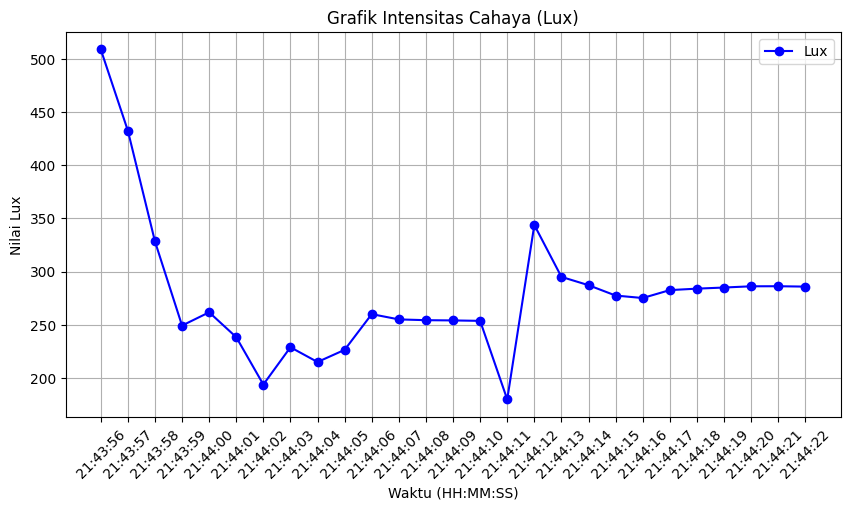

In [20]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import datetime
from tensorflow.keras.models import load_model

# Load model yang telah dilatih
model = load_model('cnn_model.h5')

# Load label kelas
class_labels = list(train_generator.class_indices.keys())

# Inisialisasi kamera
cap = cv2.VideoCapture(0)

# Faktor kalibrasi lux agar lebih akurat
LUX_CALIBRATION_FACTOR = 2.5

# Data untuk grafik
lux_values = []
timestamps = []
seen_timestamps = set()  # Set untuk menyimpan waktu unik

# Fungsi untuk menentukan kategori pencahayaan
def categorize_lux(lux):
    if lux < 60:
        return "Gelap"
    elif lux < 150:
        return "Redup"
    elif lux < 250:
        return "Sedang"
    elif lux < 350:
        return "Cukup Terang"
    else:
        return "Terang"

while True:
    ret, frame = cap.read()
    if not ret:
        break

    # Mode Night Vision
    night_vision = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
    night_vision = cv2.applyColorMap(night_vision, cv2.COLORMAP_JET)

    # Preprocessing gambar untuk prediksi
    img = cv2.resize(frame, (150, 150))
    img = img.astype("float32") / 255.0
    img = np.expand_dims(img, axis=0)

    # Prediksi kelas objek
    pred = model.predict(img)
    label = class_labels[np.argmax(pred)]

    # --- Perhitungan Lux ---
    R, G, B = frame[:, :, 2], frame[:, :, 1], frame[:, :, 0]
    luminance = (0.2126 * R + 0.7152 * G + 0.0722 * B).mean()
    lux_value = luminance * LUX_CALIBRATION_FACTOR
    category = categorize_lux(lux_value)

    # Ambil waktu saat ini (hanya detik)
    current_time = datetime.datetime.now().strftime('%H:%M:%S')

    # Simpan data ke grafik hanya jika waktu unik
    if current_time not in seen_timestamps:
        timestamps.append(current_time)
        lux_values.append(lux_value)
        seen_timestamps.add(current_time)

    # Tampilkan informasi pada frame
    cv2.putText(frame, f'Class: {label}', (50, 50), cv2.FONT_HERSHEY_SIMPLEX, 1, (0, 255, 0), 2)
    cv2.putText(frame, f'Lux: {lux_value:.2f} ({category})', (50, 90), cv2.FONT_HERSHEY_SIMPLEX, 1, (0, 255, 255), 2)
    cv2.putText(frame, f'Time: {current_time}', (50, 130), cv2.FONT_HERSHEY_SIMPLEX, 1, (255, 255, 255), 2)

    # Tampilkan frame utama dan night vision
    cv2.imshow('Frame', frame)
    cv2.imshow('Night Vision', night_vision)

    if cv2.waitKey(1) & 0xFF == ord('q'):
        break

# Tutup kamera
cap.release()
cv2.destroyAllWindows()

# --- Grafik Luxmeter ---
plt.figure(figsize=(10, 5))
plt.plot(timestamps, lux_values, marker='o', linestyle='-', color='b', label="Lux")
plt.xlabel("Waktu (HH:MM:SS)")
plt.ylabel("Nilai Lux")
plt.title("Grafik Intensitas Cahaya (Lux)")
plt.xticks(rotation=45)
plt.legend()
plt.grid(True)
plt.show()